# Project Goal: Predict "Pleasant Weather" for Each Station Based on Weather Metrics

## ✅ Problem Statement

We are given a dataset of weather metrics (temperature, humidity, cloud cover, etc.) for **15 weather stations**, recorded over time.

We also have a **"pleasant weather" label (0 or 1)** for each station at each time step, indicating whether the weather was considered pleasant at that location and date.

👉 The goal is to train a model that, given the weather conditions across all stations at a particular time, can predict **which stations are experiencing pleasant weather** (i.e., output a 0 or 1 for each of the 15 stations, at each timestep).

---
## 🧪 Model Type

* The model is **multi-label**, not multiclass — we’re predicting *15 binary outputs* (one for each station), *not* choosing *one station* per sample.

* We use a `sigmoid` activation in the final layer and `binary_crossentropy` loss, because:

  - Multiple stations can have pleasant weather **at the same time**
  - Each label (column) is independent and Boolean
---

## 🔍 Input (X)
Shape: `(samples, 15 stations, 9 weather features)`  
Each sample contains one timestamp’s weather data across all stations.

## 🎯 Target (y)
Shape: `(samples, 15)`  
Each column is a Boolean (0 or 1), indicating whether a given station had pleasant weather at that moment.

---


# 1. Import Libraries and Dataset

In [1]:
# Data manipulation and analysis
import pandas as pd          # For handling tabular data (DataFrames)
import numpy as np           # For numerical computations, arrays, etc.

# Visualization
import seaborn as sns        # For enhanced visualizations like heatmaps
import matplotlib.pyplot as plt  # Core plotting library

# File operations
import os                    # For interacting with the file system (checking paths, saving files)

# Utility functions
import operator              # For functional tools (e.g., custom sorting)

# Deep learning (Keras via TensorFlow — Colab-safe)
import tensorflow as tf      # TensorFlow base (used for model training, GPU acceleration, etc.)
from tensorflow.keras.models import Sequential       # Sequential model API
from tensorflow.keras.layers import LSTM, Dense, Dropout  # RNN layer, fully connected layer, and dropout

# Utility
from numpy import unique     # For extracting unique class labels from arrays

# Data splitting
from sklearn.model_selection import train_test_split  # Split dataset into training and testing sets

# 🔒 Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [2]:
weather_df = pd.read_csv('Dataset-weather-prediction-dataset-processed.csv')

In [3]:
# Import 'pleasant_weather'
pleasant_weather = pd.read_csv('pleasant_weather_Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv')

# 2. Dataset Clean & Process for ML

In [4]:
# Drop DATE and MONTH columns
weather_nodate = weather_df.drop(columns=['DATE', 'MONTH'])
pleasant_nodate= pleasant_weather.drop(columns=['DATE'])

In [5]:
# Drop all columns that start with TOURS_, ROMA_, or GDANSK_
weather_nodate = weather_nodate.drop(columns=[
    col for col in weather_nodate.columns
    if col.startswith('TOURS_') or col.startswith('ROMA_') or col.startswith('GDANSK_')
])


In [6]:
# Import unmelted long-form to see the weather metrics missing from most years
unmelt_df = pd.read_csv('weather_data_post_unmelt.csv')

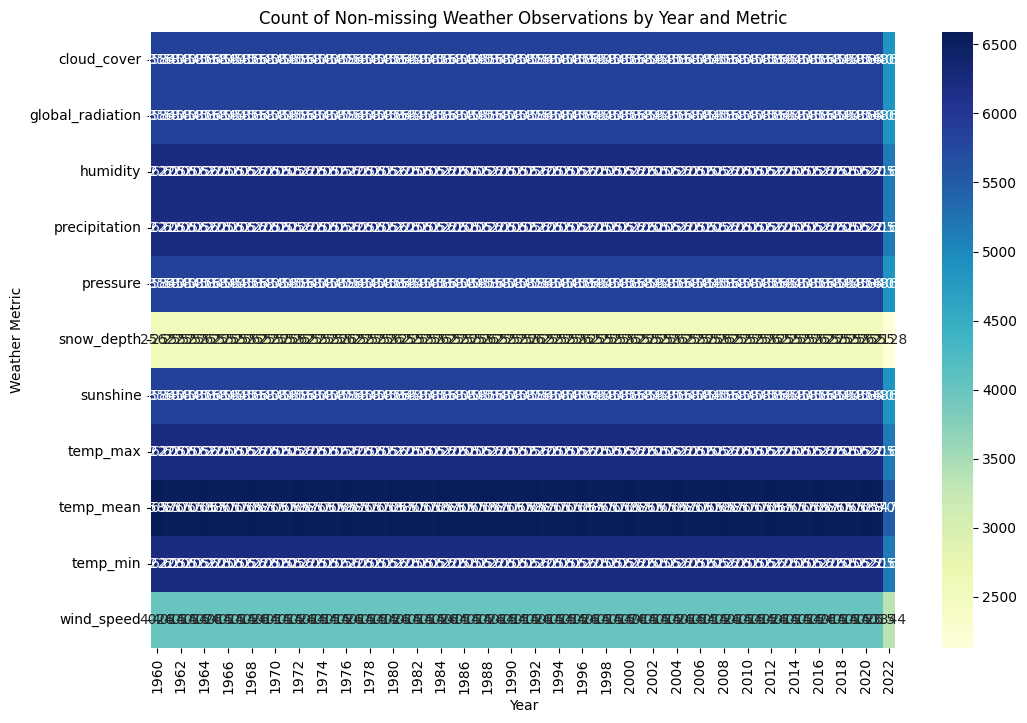

In [7]:
# List of weather metrics to check
metrics = ['cloud_cover', 'global_radiation', 'humidity', 'precipitation', 'pressure',
           'snow_depth', 'sunshine', 'temp_max', 'temp_mean', 'temp_min', 'wind_speed']

# Create a DataFrame counting non-missing entries for each year and metric
count_df = unmelt_df.groupby('year')[metrics].count()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(count_df.T, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Count of Non-missing Weather Observations by Year and Metric')
plt.xlabel('Year')
plt.ylabel('Weather Metric')
plt.show()

In [8]:
# Drop all columns that end with '_snow_depth' and '_wind_speed'
weather_nodate = weather_nodate.drop(columns=[
    col for col in weather_nodate.columns
    if col.endswith('_snow_depth') or col.endswith('_wind_speed')
])


## Finding the missing columns

In [9]:
# Step 1: Extract station-feature mapping
from collections import defaultdict

station_features = defaultdict(list)

for col in weather_nodate.columns:
    if '_' in col:
        station, feature = col.split('_', 1)
        station_features[station].append(feature)

# Step 2: Validate each station
expected_features = [
    'cloud_cover', 'humidity', 'pressure',
    'global_radiation', 'precipitation', 'sunshine',
    'temp_mean', 'temp_min', 'temp_max'
]

missing_map = {}

for station, features in station_features.items():
    missing = list(set(expected_features) - set(features))
    if missing:
        missing_map[station] = missing

# Step 3: Report
if missing_map:
    print("🚨 Missing features by station:\n")
    for station, missing in missing_map.items():
        print(f"{station}: {missing}")
else:
    print("✅ All stations have all 9 features. You're good to go.")


🚨 Missing features by station:

KASSEL: ['cloud_cover']
MUNCHENB: ['pressure']
STOCKHOLM: ['humidity']


In [10]:
### Copy LJUBLJANA_cloud_cover → assign as KASSEL_cloud_cover
### Copy SONNBLICK_pressure → assign as MUNCHENB_pressure
### Copy OSLO_humidity → assign as STOCKHOLM_humidity

# Fill in the missing columns using nearby station data
weather_nodate['KASSEL_cloud_cover'] = weather_nodate['LJUBLJANA_cloud_cover']
weather_nodate['MUNCHENB_pressure'] = weather_nodate['SONNBLICK_pressure']
weather_nodate['STOCKHOLM_humidity'] = weather_nodate['OSLO_humidity']


In [11]:
weather_nodate.shape

(22950, 135)

In [ ]:
# Export to CSV
weather_nodate.to_csv('weather_nodate_CLEANED.csv', index=False)
pleasant_nodate.to_csv('pleasant_nodate_CLEANED.csv', index=False)

In [12]:
weather_nodate.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,KASSEL_cloud_cover,MUNCHENB_pressure,STOCKHOLM_humidity
0,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,...,1.0003,0.45,0.34,4.7,8.5,6.0,10.9,8,1.0304,0.98
1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,...,1.0007,0.25,0.84,0.7,8.9,5.6,12.1,6,1.0292,0.62
2,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,...,1.0096,0.17,0.08,0.1,10.5,8.1,12.9,8,1.0320,0.69
3,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,10.6,8,...,1.0184,0.13,0.98,0.0,7.4,7.3,10.6,6,1.0443,0.98
4,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,6.0,8,...,1.0328,0.46,0.00,5.7,5.7,3.0,8.4,7,1.0430,0.96


In [13]:
pleasant_nodate.head()

,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# 3. Set-up X and y

In [16]:
# X: weather metrics across 15 stations (without DATE)
X = weather_nodate.to_numpy()
X = X.reshape(-1, 15, 9)  # (samples, stations, features)
print("X shape:", X.shape)  # → (22950, 15, 9)

# y: pleasant weather for each station (also without DATE)
y = pleasant_nodate.to_numpy()
y = y.reshape(-1, 15)  # (samples, stations)
print("y shape:", y.shape)  # → (22950, 15)


X shape: (22950, 15, 9)
y shape: (22950, 15)


# 4. Train and Split Test

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (18360, 15, 9) (18360, 15)
Test shape: (4590, 15, 9) (4590, 15)


# 5. Build and Train Model #1

### 🔍 Why **CNN** over **RNN** for this project?

We used a **Convolutional Neural Network (CNN)** because the input data represents **multiple weather stations (spatial structure)** per timestep, not a **sequence of time points** per station.
CNNs can learn spatial patterns across stations (e.g., “if station A and B have low cloud cover, station C is likely pleasant”).

---
Our data is:

```
(sample = all stations at one date) → shape: (num_samples, stations, features)
```

...which is better suited to **CNN**, since we’re treating this as a spatial prediction across locations.

---


### ⚙️ Key Hyperparameters Used

| Hyperparameter       | Value                     |
|----------------------|---------------------------|
| Convolution filters  | 32                        |
| Kernel size          | 2                         |
| Epochs               | 20                        |
| Batch size           | 64                        |
| Loss function        | Binary Crossentropy       |
| Activation functions | ReLU (Conv), Sigmoid (Dense) |
| Optimizer            | Adam                      |
| Dropout rate         | 0.3                       |

*Note: Learning rate is not explicitly set—so it's using the default learning rate of **`0.001`** in the Adam optimizer.*

---

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Model parameters
v1_input_shape = (15, 9)  # 15 stations, each with 9 weather features — like 15 parallel weather snapshots
v1_epochs = 20            # Number of times the model will iterate over the entire training dataset
v1_batch_size = 64        # Number of samples the model processes before updating weights (i.e., per training step)

v1_model = Sequential()

# 1D Convolution layer: extract local patterns across stations/features
v1_model.add(Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=v1_input_shape))

# Pooling to reduce dimensionality
v1_model.add(MaxPooling1D(pool_size=2))

# Flatten to convert 3D tensor to 2D for Dense layer
v1_model.add(Flatten())

# Dropout to reduce overfitting
v1_model.add(Dropout(0.3))

# Final Dense layer with 15 outputs (one per station)
# Sigmoid activation because it's multilabel binary classification (each output 0/1)
v1_model.add(Dense(15, activation='sigmoid'))

# Compile the model with binary_crossentropy for multilabel classification
v1_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

v1_model.summary()

# Train the model
v1_history = v1_model.fit(
    X_train, y_train,
    epochs= v1_epochs,
    batch_size= v1_batch_size,
    validation_split=0.2,
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 14, 32)         │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         3,375 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,983 (15.56 KB)

 Trainable params: 3,983 (15.56 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1109 - loss: 0.9431 - val_accuracy: 0.1373 - val_loss: 0.2575
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1568 - loss: 0.2865 - val_accuracy: 0.1699 - val_loss: 0.2336
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1760 - loss: 0.2564 - val_accuracy: 0.1811 - val_loss: 0.2218
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1793 - loss: 0.2436 - val_accuracy: 0.1735 - val_loss: 0.2154
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1711 - loss: 0.2356 - val_accuracy: 0.1708 - val_loss: 0.2081
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1724 - loss: 0.2297 - val_accuracy: 0.1724 - val_loss: 0.2042
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1708 - loss: 0.2241 - val_accuracy: 0.1732 - val_loss: 0.1995
Epoch 8/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1729 - loss: 0.2203 - val_accuracy: 0.

# 6. Evaluate the Model & Visualize Training Progress (Model #1)

In [24]:
from sklearn.metrics import classification_report

# Predict
v1_y_pred = v1_model.predict(X_test)
v1_y_pred_binary = (v1_y_pred > 0.5).astype(int)  # Threshold predictions

# Flatten both for evaluation
v1_y_test_flat = y_test.flatten()
v1_y_pred_flat = v1_y_pred_binary.flatten()

print(classification_report(v1_y_test_flat, v1_y_pred_flat, zero_division=0))


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     54360
           1       0.80      0.81      0.81     14490

    accuracy                           0.92     68850
   macro avg       0.88      0.88      0.88     68850
weighted avg       0.92      0.92      0.92     68850



In [25]:
# Get predicted probabilities
v1_station_y_pred_prob = v1_model.predict(X_test)

# Convert probabilities to binary predictions (threshold = 0.5)
v1_station_y_pred = (v1_station_y_pred_prob >= 0.5).astype(int)

# Generate classification report
# Assuming your station names are known (optional, but makes it cleaner)
station_names = ['BASEL', 'BELGRADE', 'BUDAPEST', 'DEBILT', 'DUSSELDORF',
                 'HEATHROW', 'KASSEL', 'LJUBLJANA', 'MAASTRICHT', 'MADRID',
                 'MUNCHENB', 'OSLO', 'SONNBLICK', 'STOCKHOLM', 'VALENTIA']

print("📍 Classification Report per Station:")
print(classification_report(y_test, v1_station_y_pred, target_names=station_names, zero_division=0))


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
📍 Classification Report per Station:
              precision    recall  f1-score   support

       BASEL       0.77      0.80      0.78      1099
    BELGRADE       0.80      0.84      0.82      1561
    BUDAPEST       0.78      0.87      0.82      1461
      DEBILT       0.77      0.80      0.78       878
  DUSSELDORF       0.76      0.79      0.78       975
    HEATHROW       0.76      0.77      0.76       935
      KASSEL       0.80      0.73      0.77       743
   LJUBLJANA       0.79      0.83      0.81      1229
  MAASTRICHT       0.80      0.80      0.80       933
      MADRID       0.88      0.94      0.91      2033
    MUNCHENB       0.83      0.78      0.80       952
        OSLO       0.82      0.67      0.74       675
   SONNBLICK       0.00      0.00      0.00         0
   STOCKHOLM       0.81      0.71      0.75       788
    VALENTIA       0.79      0.39      0.53       228

   micro avg       0.80      0.81      0.81     14490
  

144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1624 - loss: 0.1811
Test Loss: 0.1827
Test Accuracy: 0.1632


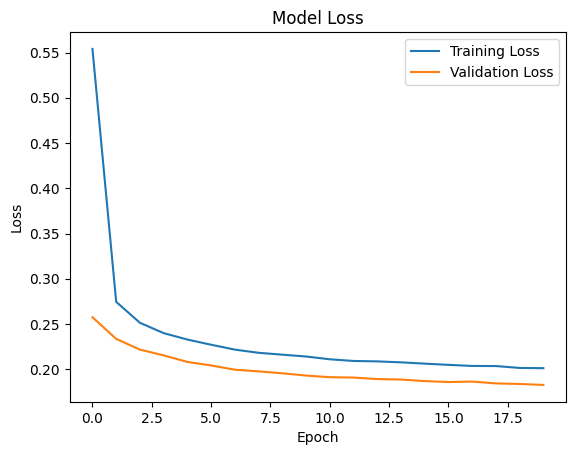

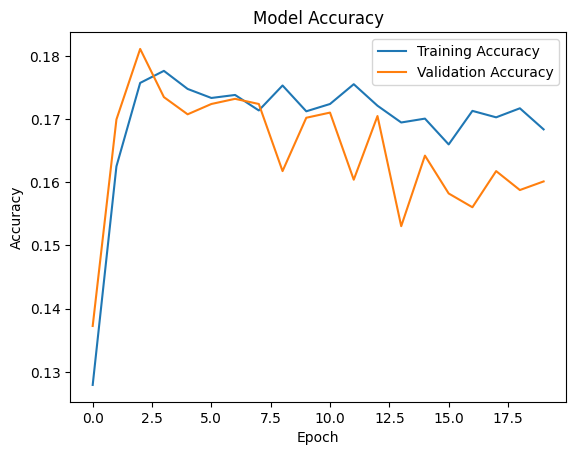

In [26]:
# Final test set performance
loss, accuracy = v1_model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


# Loss plot
plt.plot(v1_history.history['loss'], label='Training Loss')
plt.plot(v1_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Accuracy plot
plt.plot(v1_history.history['accuracy'], label='Training Accuracy')
plt.plot(v1_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


# 7. Confusion Matrix Per Station

- Across the 15 stations, the CNN model performs consistently well in identifying the majority clas "unpleasant weather" days, with F1-scores generally above 0.90.
- The model also shows strong performance on the minority class (pleasant days), with most stations reaching F1-scores between 0.75–0.85.
- Exceptions are expected and explainable: Valentia, for instance, has a significantly imbalanced distribution (only 5% pleasant), resulting in lower performance for that class.
- Madrid stands out as a strong success case, likely due to its balanced and stable Mediterranean weather profile.
- The model appears to generalize well across stations of varying climates and class distributions.

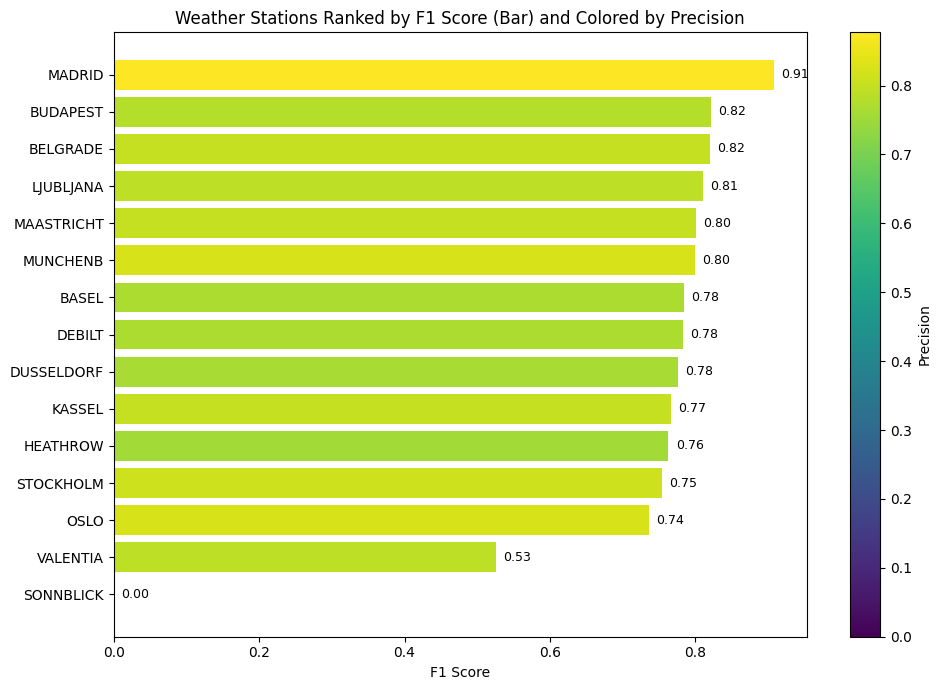

In [40]:
from sklearn.metrics import f1_score, recall_score, precision_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

station_f1_scores = {}
station_recall_scores = {}
station_precision_scores = {}

for i, station in enumerate(station_names):
    f1 = f1_score(y_test[:, i], v1_station_y_pred[:, i], zero_division=0)
    recall = recall_score(y_test[:, i], v1_station_y_pred[:, i], zero_division=0)
    precision = precision_score(y_test[:, i], v1_station_y_pred[:, i], zero_division=0)
    station_f1_scores[station] = f1
    station_recall_scores[station] = recall
    station_precision_scores[station] = precision

# Create DataFrame
df = pd.DataFrame({
    'F1 Score': pd.Series(station_f1_scores),
    'Recall': pd.Series(station_recall_scores),
    'Precision': pd.Series(station_precision_scores)
})

# Sort by F1 Score ascending for horizontal bar chart
df = df.sort_values('F1 Score', ascending=True)

# Normalize Precision for coloring (between 0 and 1)
norm_precision = (df['Precision'] - df['Precision'].min()) / (df['Precision'].max() - df['Precision'].min())

# Choose a colormap: plt.cm.RdBu for Red-Blue, or plt.cm.RdYlGn for Yellow-Green
cmap = plt.cm.viridis

# Map normalized precision to colors
colors = cmap(norm_precision)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(df.index, df['F1 Score'], color=colors)

for bar, val in zip(bars, df['F1 Score']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)


ax.set_xlabel('F1 Score')
ax.set_title('Weather Stations Ranked by F1 Score (Bar) and Colored by Precision')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=df['Precision'].min(), vmax=df['Precision'].max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Precision')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Threshold sigmoid outputs at 0.5 to get binary predictions
y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)

# Now compute classification report PER STATION
for i, station in enumerate(pleasant_nodate.columns):
    print(f"\n📍 {station}")
    print(classification_report(y_test[:, i], y_pred_binary[:, i], zero_division=0))


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📍 BASEL_pleasant_weather
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      3491
           1       0.76      0.81      0.79      1099

    accuracy                           0.89      4590
   macro avg       0.85      0.87      0.86      4590
weighted avg       0.90      0.89      0.89      4590


📍 BELGRADE_pleasant_weather
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      3029
           1       0.79      0.88      0.83      1561

    accuracy                           0.88      4590
   macro avg       0.86      0.88      0.87      4590
weighted avg       0.88      0.88      0.88      4590


📍 BUDAPEST_pleasant_weather
              precision    recall  f1-score   support

           0       0.94      0.89      0.91      3129
           1       0.78      0.87      0.83      1461

    accuracy                           0.88      4590
   

# 9. Build and Train Model #2

| Hyperparameter       | Value                                                   | Rationale                                                                     |
| -------------------- | ------------------------------------------------------- | ----------------------------------------------------------------------------- |
| Convolution filters  | 32                                                      | Baseline size to capture local patterns                                       |
| Kernel size          | 2                                                       | Small size to focus on immediate station relationships                        |
| Epochs (max)         | 15                                                      | Reduced from 20 — convergence appeared to occur earlier                       |
| Batch size           | 64                                                      | Standard balance of speed and stability                                       |
| Loss function        | Binary Crossentropy                                     | Required for multilabel classification                                        |
| Activation functions | ReLU (Conv), Sigmoid (Dense)                            | ReLU for nonlinear feature extraction, Sigmoid for independent binary outputs |
| Optimizer            | Adam                                                    | Fast convergence, widely used for CNNs                                        |
| Dropout rate         | 0.1                                                     | Decreased from 0.3 to reduce signs of underfitting (val acc flat + low)       |
| **EarlyStopping**    | Patience = 3, Monitor = `val_loss`, Restore Best = True | Added to prevent overfitting after lowering regularization (dropout)          |


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()
model.add(Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(15, 9)))
# Optional second layer for added capacity
model.add(Conv1D(filters=64, kernel_size=2, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dropout(0.1))  # reduced from 0.3
model.add(Dense(32, activation='relu'))  # optional intermediate dense layer
model.add(Dense(15, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


In [41]:
#from sklearn.model_selection import train_test_split
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: First split your data into training and temp (to later split into val/test)
# This keeps your final test set completely untouched during training/validation.
v2_X_train_full, v2_X_temp, v2_y_train_full, v2_y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Split temp into validation and test
# Why? Because EarlyStopping needs a validation set to monitor performance.
v2_X_val, v2_X_test, v2_y_val, v2_y_test = train_test_split(v2_X_temp, v2_y_temp, test_size=0.5, random_state=42)

# Confirm the shapes
print("Training shape:", v2_X_train_full.shape, v2_y_train_full.shape)
print("Validation shape:", v2_X_val.shape, v2_y_val.shape)
print("Test shape:", v2_X_test.shape, v2_y_test.shape)


# Model parameters
v2_input_shape = (15, 9)  # 15 stations, each with 9 weather features — like 15 parallel weather snapshots
v2_epochs = 15            # Drop down from 20
v2_batch_size = 64

# Step 3: Build the CNN model
v2_model = Sequential()

# 1D Convolution: learn patterns across stations/features
v2_model.add(Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=v2_input_shape))

# Downsample with pooling
v2_model.add(MaxPooling1D(pool_size=2))

# Flatten for dense connection
v2_model.add(Flatten())

# Dropout: reduced to 0.1 to address possible underfitting
v2_model.add(Dropout(0.1))

# Output: 15 binary predictions (one per weather station)
v2_model.add(Dense(15, activation='sigmoid'))

# Compile the model with loss and optimizer suited for multilabel binary classification
v2_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

v2_model.summary()

# Step 4: Set up EarlyStopping
# Why? To stop training *before* overfitting if validation loss starts rising.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Step 5: Train the model with early stopping using the validation set
v2_history = v2_model.fit(
    v2_X_train_full, v2_y_train_full,
    epochs=15,
    batch_size=64,
    validation_data=(v2_X_val, v2_y_val),
    callbacks=[early_stop]
)


Training shape: (18360, 15, 9) (18360, 15)
Validation shape: (2295, 15, 9) (2295, 15)
Test shape: (2295, 15, 9) (2295, 15)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 14, 32)         │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         3,375 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,983 (15.56 KB)

 Trainable params: 3,983 (15.56 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1074 - loss: 0.6633 - val_accuracy: 0.1952 - val_loss: 0.2477
Epoch 2/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1711 - loss: 0.2663 - val_accuracy: 0.1961 - val_loss: 0.2211
Epoch 3/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1791 - loss: 0.2340 - val_accuracy: 0.1948 - val_loss: 0.2076
Epoch 4/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1764 - loss: 0.2188 - val_accuracy: 0.1943 - val_loss: 0.2002
Epoch 5/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1749 - loss: 0.2113 - val_accuracy: 0.1882 - val_loss: 0.1951
Epoch 6/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1746 - loss: 0.2056 - val_accuracy: 0.1878 - val_loss: 0.1918
Epoch 7/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1781 - loss: 0.2021 - val_accuracy: 0.1930 - val_loss: 0.1891
Epoch 8/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1750 - loss: 0.1997 - val_accuracy: 0.

# 10. Evaluate (Model #2)

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2016 - loss: 0.1783
Test Loss: 0.1757
Test Accuracy: 0.1974


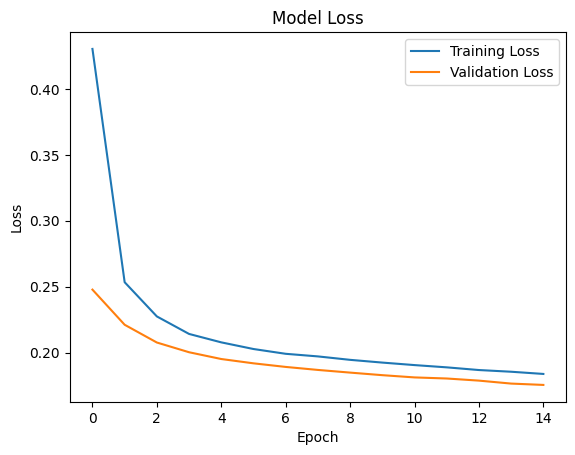

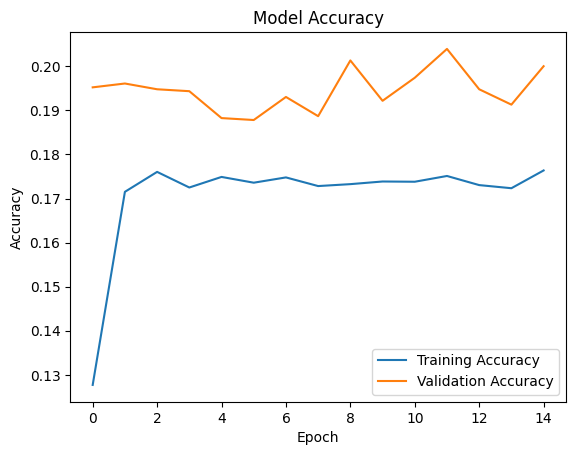

In [42]:
# Final test set performance
v2_loss, v2_accuracy = v2_model.evaluate(v2_X_test, v2_y_test)
print(f"Test Loss: {v2_loss:.4f}")
print(f"Test Accuracy: {v2_accuracy:.4f}")


# Loss plot
plt.plot(v2_history.history['loss'], label='Training Loss')
plt.plot(v2_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Accuracy plot
plt.plot(v2_history.history['accuracy'], label='Training Accuracy')
plt.plot(v2_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [43]:
# Predict
v2_y_pred = v2_model.predict(v2_X_test)
v2_y_pred_binary = (v2_y_pred > 0.5).astype(int)  # Threshold predictions

# Flatten both for evaluation
v2_y_test_flat = v2_y_test.flatten()
v2_y_pred_flat = v2_y_pred_binary.flatten()

print(classification_report(v2_y_test_flat, v2_y_pred_flat, zero_division=0))


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     27195
           1       0.82      0.80      0.81      7230

    accuracy                           0.92     34425
   macro avg       0.88      0.88      0.88     34425
weighted avg       0.92      0.92      0.92     34425



In [44]:
# Get predicted probabilities
v2_station_y_pred_prob = v2_model.predict(v2_X_test)

# Convert probabilities to binary predictions (threshold = 0.5)
v2_station_y_pred = (v2_station_y_pred_prob >= 0.5).astype(int)

# Generate classification report
# Assuming your station names are known (optional, but makes it cleaner)
station_names = ['BASEL', 'BELGRADE', 'BUDAPEST', 'DEBILT', 'DUSSELDORF',
                 'HEATHROW', 'KASSEL', 'LJUBLJANA', 'MAASTRICHT', 'MADRID',
                 'MUNCHENB', 'OSLO', 'SONNBLICK', 'STOCKHOLM', 'VALENTIA']

print("📍 Classification Report per Station:")
print(classification_report(v2_y_test, v2_station_y_pred, target_names=station_names, zero_division=0))


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step
📍 Classification Report per Station:
              precision    recall  f1-score   support

       BASEL       0.79      0.83      0.81       544
    BELGRADE       0.83      0.85      0.84       789
    BUDAPEST       0.78      0.84      0.81       709
      DEBILT       0.80      0.74      0.77       431
  DUSSELDORF       0.79      0.75      0.77       493
    HEATHROW       0.82      0.72      0.77       461
      KASSEL       0.86      0.71      0.78       387
   LJUBLJANA       0.84      0.82      0.83       620
  MAASTRICHT       0.80      0.80      0.80       466
      MADRID       0.92      0.88      0.90       994
    MUNCHENB       0.80      0.84      0.82       474
        OSLO       0.79      0.78      0.79       338
   SONNBLICK       0.00      0.00      0.00         0
   STOCKHOLM       0.83      0.72      0.77       412
    VALENTIA       0.64      0.39      0.49       112

   micro avg       0.82      0.80      0.81      7230
  

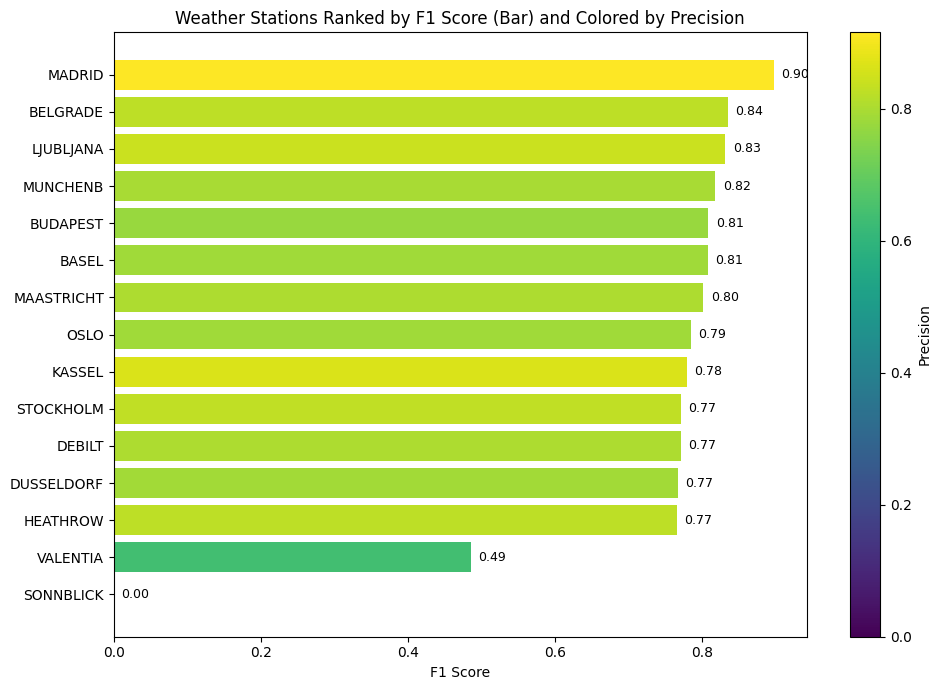

In [45]:
v2_station_f1_scores = {}
v2_station_recall_scores = {}
v2_station_precision_scores = {}

for i, station in enumerate(station_names):
    v2_f1 = f1_score(v2_y_test[:, i], v2_station_y_pred[:, i], zero_division=0)
    v2_recall = recall_score(v2_y_test[:, i], v2_station_y_pred[:, i], zero_division=0)
    v2_precision = precision_score(v2_y_test[:, i], v2_station_y_pred[:, i], zero_division=0)
    v2_station_f1_scores[station] = v2_f1
    v2_station_recall_scores[station] = v2_recall
    v2_station_precision_scores[station] = v2_precision

# Create DataFrame
v2_df = pd.DataFrame({
    'F1 Score': pd.Series(v2_station_f1_scores),
    'Recall': pd.Series(v2_station_recall_scores),
    'Precision': pd.Series(v2_station_precision_scores)
})

# Sort by F1 Score ascending for horizontal bar chart
v2_df = v2_df.sort_values('F1 Score', ascending=True)

# Normalize Precision for coloring (between 0 and 1)
v2_norm_precision = (v2_df['Precision'] - v2_df['Precision'].min()) / (v2_df['Precision'].max() - v2_df['Precision'].min())

# Choose a colormap: plt.cm.RdBu for Red-Blue, or plt.cm.RdYlGn for Yellow-Green
cmap = plt.cm.viridis

# Map normalized precision to colors
colors = cmap(v2_norm_precision)

fig1, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(v2_df.index, v2_df['F1 Score'], color=colors)

for bar, val in zip(bars, v2_df['F1 Score']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)


ax.set_xlabel('F1 Score')
ax.set_title('Weather Stations Ranked by F1 Score (Bar) and Colored by Precision')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=v2_df['Precision'].min(), vmax=v2_df['Precision'].max()))
sm.set_array([])
cbar = fig1.colorbar(sm, ax=ax)
cbar.set_label('Precision')

plt.tight_layout()
plt.show()


# 11. Build and Train Model #3

What We’ll Explore in v3_model (Simple CNN Tweaks)
- ✅ 1. Add a second Conv1D layer
Helps model learn more hierarchical spatial features across stations.

Often a gentle improvement without making things too complex.

- ✅ 2. Increase kernel size from 2 to 3
Slightly wider spatial window per convolution.

Means the model "sees" a bit more of the neighborhood per station interaction.

- ✅ 3. Try smaller batch size (32 instead of 64)
More frequent weight updates; may lead to better generalization (but slower training).

Great for subtle pattern learning in small-to-medium datasets.

### ⚙️ Key Hyperparameters Used (Model #3)
| Hyperparameter       | Value                        |
| -------------------- | ---------------------------- |
| Conv layers          | 2 (both with 32 filters)     |
| Kernel size          | 3                            |
| Dropout              | 0.15                         |
| Epochs               | 15                           |
| Batch size           | 32                           |
| Loss                 | Binary Crossentropy          |
| Optimizer            | Adam                         |
| Activation functions | ReLU (Conv), Sigmoid (Dense) |


In [47]:
# Build model
v3_model = Sequential()

# First convolution
v3_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(15, 9)))
v3_model.add(MaxPooling1D(pool_size=2))

# Second convolution (no input shape needed here)
v3_model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
v3_model.add(MaxPooling1D(pool_size=2))

v3_model.add(Flatten())
v3_model.add(Dropout(0.15))
v3_model.add(Dense(15, activation='sigmoid'))

v3_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

v3_model.summary()

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train model
v3_history = v3_model.fit(
    v2_X_train_full, v2_y_train_full,
    epochs=15,
    batch_size=32,  # smaller batch for more frequent updates
    validation_data=(v2_X_val, v2_y_val),
    callbacks=[early_stop]
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 13, 32)         │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 4, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,975 (19.43 KB)

 Trainable params: 4,975 (19.43 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1399 - loss: 0.5241 - val_accuracy: 0.1704 - val_loss: 0.2355
Epoch 2/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1798 - loss: 0.2494 - val_accuracy: 0.1839 - val_loss: 0.2168
Epoch 3/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1824 - loss: 0.2320 - val_accuracy: 0.2052 - val_loss: 0.2061
Epoch 4/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1859 - loss: 0.2221 - val_accuracy: 0.1895 - val_loss: 0.2004
Epoch 5/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1862 - loss: 0.2150 - val_accuracy: 0.1996 - val_loss: 0.1961
Epoch 6/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1898 - loss: 0.2101 - val_accuracy: 0.1830 - val_loss: 0.1941
Epoch 7/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1918 - loss: 0.2051 - val_accuracy: 0.1991 - val_loss: 0.1880
Epoch 8/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1942 - loss: 0.2021 - val_accuracy: 0.

# 12. Evaluate (Model #3)

144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2119 - loss: 0.1723
Test Loss: 0.1740
Test Accuracy: 0.2000


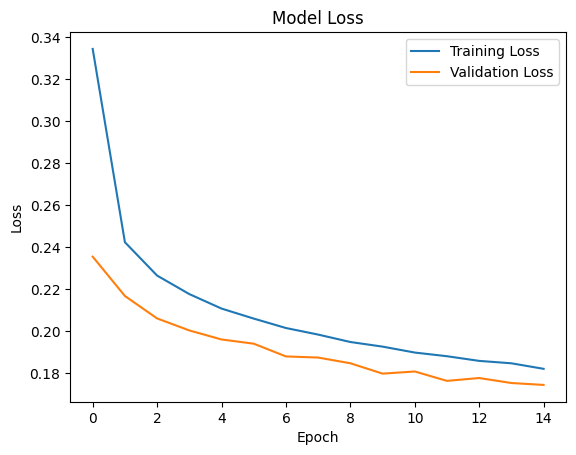

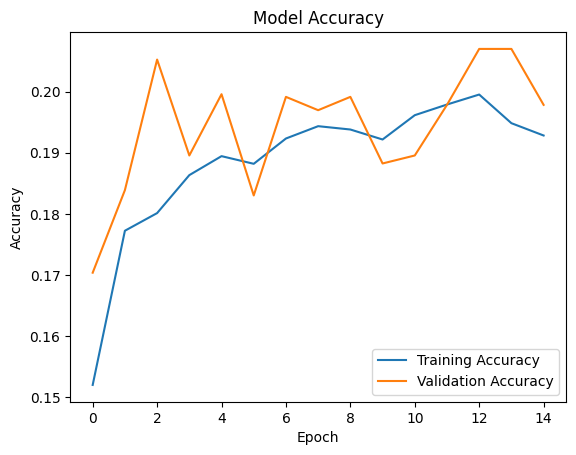

In [48]:
# Final test set performance
loss, accuracy = v3_model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


# Loss plot
plt.plot(v3_history.history['loss'], label='Training Loss')
plt.plot(v3_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Accuracy plot
plt.plot(v3_history.history['accuracy'], label='Training Accuracy')
plt.plot(v3_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [49]:
# Predict
v3_y_pred = v3_model.predict(X_test)
v3_y_pred_binary = (v3_y_pred > 0.5).astype(int)  # Threshold predictions

# Flatten both for evaluation
v3_y_test_flat = y_test.flatten()
v3_y_pred_flat = v3_y_pred_binary.flatten()

print(classification_report(v3_y_test_flat, v3_y_pred_flat, zero_division=0))


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     54360
           1       0.84      0.78      0.81     14490

    accuracy                           0.92     68850
   macro avg       0.89      0.87      0.88     68850
weighted avg       0.92      0.92      0.92     68850



In [51]:
# Get predicted probabilities
v3_station_y_pred_prob = v3_model.predict(X_test)

# Convert probabilities to binary predictions (threshold = 0.5)
v3_station_y_pred = (v3_station_y_pred_prob >= 0.5).astype(int)

# Generate classification report
# Assuming your station names are known (optional, but makes it cleaner)
station_names = ['BASEL', 'BELGRADE', 'BUDAPEST', 'DEBILT', 'DUSSELDORF',
                 'HEATHROW', 'KASSEL', 'LJUBLJANA', 'MAASTRICHT', 'MADRID',
                 'MUNCHENB', 'OSLO', 'SONNBLICK', 'STOCKHOLM', 'VALENTIA']

print("📍 Classification Report per Station:")
print(classification_report(y_test, v3_station_y_pred, target_names=station_names, zero_division=0))


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
📍 Classification Report per Station:
              precision    recall  f1-score   support

       BASEL       0.81      0.76      0.79      1099
    BELGRADE       0.85      0.86      0.86      1561
    BUDAPEST       0.85      0.78      0.81      1461
      DEBILT       0.83      0.73      0.78       878
  DUSSELDORF       0.83      0.77      0.80       975
    HEATHROW       0.77      0.77      0.77       935
      KASSEL       0.88      0.65      0.75       743
   LJUBLJANA       0.82      0.81      0.82      1229
  MAASTRICHT       0.85      0.76      0.81       933
      MADRID       0.92      0.89      0.91      2033
    MUNCHENB       0.85      0.75      0.79       952
        OSLO       0.78      0.77      0.77       675
   SONNBLICK       0.00      0.00      0.00         0
   STOCKHOLM       0.80      0.73      0.76       788
    VALENTIA       0.39      0.03      0.06       228

   micro avg       0.84      0.78      0.81     14490
  

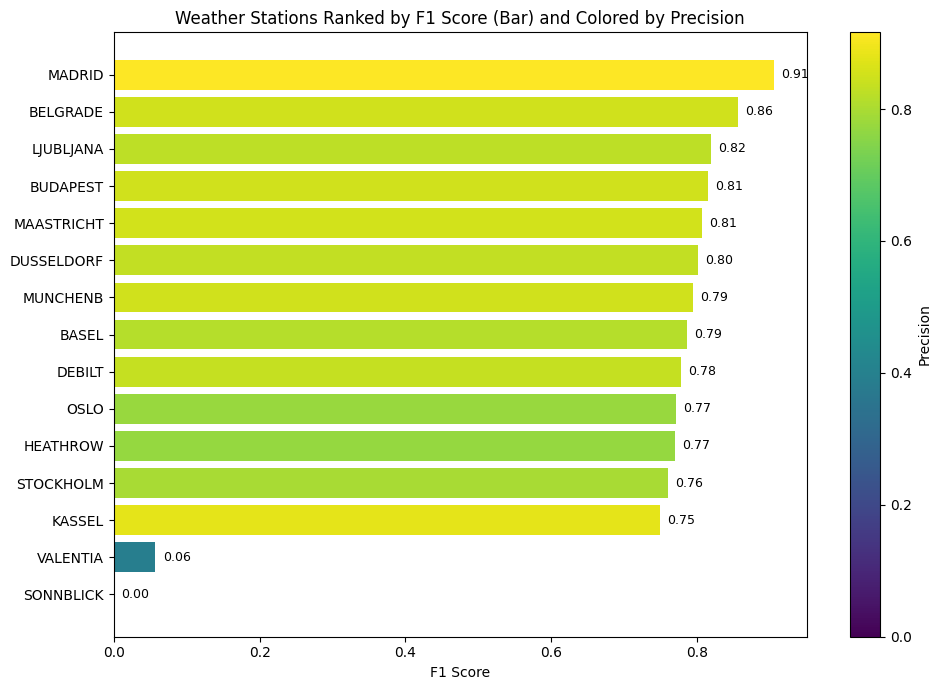

In [52]:
v3_station_f1_scores = {}
v3_station_recall_scores = {}
v3_station_precision_scores = {}

for i, station in enumerate(station_names):
    v3_f1 = f1_score(y_test[:, i], v3_station_y_pred[:, i], zero_division=0)
    v3_recall = recall_score(y_test[:, i], v3_station_y_pred[:, i], zero_division=0)
    v3_precision = precision_score(y_test[:, i], v3_station_y_pred[:, i], zero_division=0)
    v3_station_f1_scores[station] = v3_f1
    v3_station_recall_scores[station] = v3_recall
    v3_station_precision_scores[station] = v3_precision

# Create DataFrame
v3_df = pd.DataFrame({
    'F1 Score': pd.Series(v3_station_f1_scores),
    'Recall': pd.Series(v3_station_recall_scores),
    'Precision': pd.Series(v3_station_precision_scores)
})

# Sort by F1 Score ascending for horizontal bar chart
v3_df = v3_df.sort_values('F1 Score', ascending=True)

# Normalize Precision for coloring (between 0 and 1)
v3_norm_precision = (v3_df['Precision'] - v3_df['Precision'].min()) / (v3_df['Precision'].max() - v3_df['Precision'].min())

# Choose a colormap: plt.cm.RdBu for Red-Blue, or plt.cm.RdYlGn for Yellow-Green
cmap = plt.cm.viridis

# Map normalized precision to colors
colors = cmap(v3_norm_precision)

fig2, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(v3_df.index, v3_df['F1 Score'], color=colors)

for bar, val in zip(bars, v3_df['F1 Score']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)


ax.set_xlabel('F1 Score')
ax.set_title('Weather Stations Ranked by F1 Score (Bar) and Colored by Precision')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=v3_df['Precision'].min(), vmax=v3_df['Precision'].max()))
sm.set_array([])
cbar = fig2.colorbar(sm, ax=ax)
cbar.set_label('Precision')

plt.tight_layout()
plt.show()
